# Experimental and Validation Pipeline

Run the code cell to create a publication-ready workflow figure. The notebook saves both a 300 dpi PNG and a vector PDF in the `figures` directory.

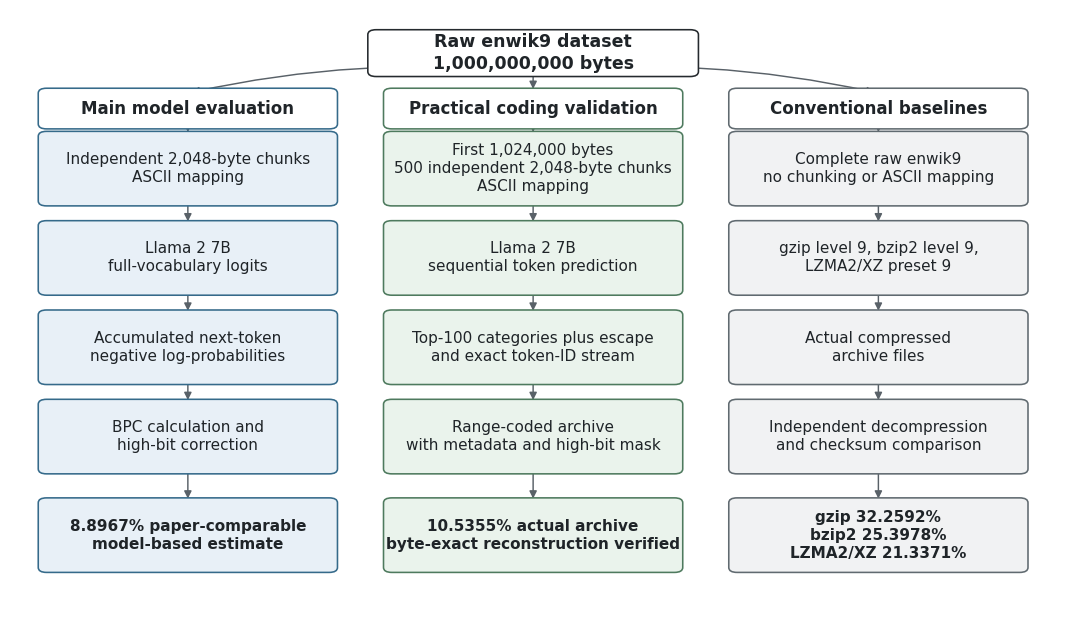

Saved PNG: /Users/wangyixuan/Documents/LLM Compression/figures/experimental_pipeline.png
Saved PDF: /Users/wangyixuan/Documents/LLM Compression/figures/experimental_pipeline.pdf


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11.5,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = {
    "source_fill": "#FFFFFF",
    "source_edge": "#252A2E",
    "theory_fill": "#E8F0F7",
    "theory_edge": "#356A8A",
    "practical_fill": "#EAF3EC",
    "practical_edge": "#4E7A5E",
    "baseline_fill": "#F1F2F3",
    "baseline_edge": "#606A70",
    "arrow": "#596168",
    "text": "#1F2428",
}

fig, ax = plt.subplots(figsize=(13.5, 8.0), facecolor="white")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def add_box(x, y, width, height, text, fill, edge, *, weight="normal", fontsize=11.0):
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.008,rounding_size=0.008",
        linewidth=1.15,
        edgecolor=edge,
        facecolor=fill,
        zorder=2,
    )
    ax.add_patch(patch)
    ax.text(
        x + width / 2, y + height / 2, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight=weight,
        color=COLORS["text"], linespacing=1.25, zorder=3,
    )
    return {"x": x, "y": y, "w": width, "h": height}

def connect(start, end, *, color=COLORS["arrow"], rad=0.0):
    x1 = start["x"] + start["w"] / 2
    y1 = start["y"]
    x2 = end["x"] + end["w"] / 2
    y2 = end["y"] + end["h"]
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=1.05,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=3, shrinkB=3, zorder=1,
    )
    ax.add_patch(arrow)

source = add_box(
    0.35, 0.900, 0.30, 0.060,
    "Raw enwik9 dataset\n1,000,000,000 bytes",
    COLORS["source_fill"], COLORS["source_edge"],
    weight="bold", fontsize=12.5,
)

columns = {
    "theory": {"x": 0.035, "fill": COLORS["theory_fill"], "edge": COLORS["theory_edge"]},
    "practical": {"x": 0.365, "fill": COLORS["practical_fill"], "edge": COLORS["practical_edge"]},
    "baseline": {"x": 0.695, "fill": COLORS["baseline_fill"], "edge": COLORS["baseline_edge"]},
}
box_w, box_h = 0.270, 0.105
levels = [0.690, 0.545, 0.400, 0.255, 0.095]

heading_nodes = {
    "theory": add_box(0.035, 0.815, box_w, 0.050, "Main model evaluation",
                      "#FFFFFF", COLORS["theory_edge"], weight="bold", fontsize=12.0),
    "practical": add_box(0.365, 0.815, box_w, 0.050, "Practical coding validation",
                         "#FFFFFF", COLORS["practical_edge"], weight="bold", fontsize=12.0),
    "baseline": add_box(0.695, 0.815, box_w, 0.050, "Conventional baselines",
                        "#FFFFFF", COLORS["baseline_edge"], weight="bold", fontsize=12.0),
}

theory_text = [
    "Independent 2,048-byte chunks\nASCII mapping",
    "Llama 2 7B\nfull-vocabulary logits",
    "Accumulated next-token\nnegative log-probabilities",
    "BPC calculation and\nhigh-bit correction",
    "8.8967% paper-comparable\nmodel-based estimate",
]
practical_text = [
    "First 1,024,000 bytes\n500 independent 2,048-byte chunks\nASCII mapping",
    "Llama 2 7B\nsequential token prediction",
    "Top-100 categories plus escape\nand exact token-ID stream",
    "Range-coded archive\nwith metadata and high-bit mask",
    "10.5355% actual archive\nbyte-exact reconstruction verified",
]
baseline_text = [
    "Complete raw enwik9\nno chunking or ASCII mapping",
    "gzip level 9, bzip2 level 9,\nLZMA2/XZ preset 9",
    "Actual compressed\narchive files",
    "Independent decompression\nand checksum comparison",
    "gzip 32.2592%\nbzip2 25.3978%\nLZMA2/XZ 21.3371%",
]

nodes = {}
for key, labels in (("theory", theory_text), ("practical", practical_text), ("baseline", baseline_text)):
    style = columns[key]
    nodes[key] = [
        add_box(style["x"], y, box_w, box_h, label, style["fill"], style["edge"],
                weight="bold" if index == 4 else "normal")
        for index, (y, label) in enumerate(zip(levels, labels))
    ]

connect(source, heading_nodes["theory"], rad=0.08)
connect(source, heading_nodes["practical"], rad=0.00)
connect(source, heading_nodes["baseline"], rad=-0.08)
for key, branch in nodes.items():
    connect(heading_nodes[key], branch[0])
    for upper, lower in zip(branch, branch[1:]):
        connect(upper, lower)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)
png_path = output_dir / "experimental_pipeline.png"
pdf_path = output_dir / "experimental_pipeline.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")
